# Laboratorio 2: Deep Learning (Avance)
**CC3084 – Data Science | UVG | Semestre II 2026**

**Avance requerido (30 de julio de 2026):** al menos dos modelos LSTM, con tuneo de parámetros, para dos de las series construidas en el Laboratorio 1 (ingreso de viajeros internacionales a Guatemala).

**Series seleccionadas:** `Total` (serie obligatoria) y `Tipo_Turista` (categoría Tipo de viajero), usando exactamente la misma partición entrenamiento/prueba del Laboratorio 1 (corte cronológico 70/30: entrenamiento ene-2009 a mar-2021, prueba abr-2021 a jun-2026).


In [1]:
import warnings
warnings.filterwarnings('ignore')
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
TEAL = '#0B7285'

MESES = {'Ene':1,'Feb':2,'Mar':3,'Abr':4,'May':5,'Jun':6,
         'Jul':7,'Ago':8,'Sep':9,'Oct':10,'Nov':11,'Dic':12}


## 1. Carga de datos y reconstrucción de las series del Laboratorio 1

Se replica exactamente la misma carga, partición cronológica (70/30) y construcción de series mensuales usadas en el Laboratorio 1, para garantizar que los modelos LSTM se comparen con los mismos conjuntos de entrenamiento/prueba.


In [2]:
df = pd.read_excel('Base_Migracion_2009-2026jun.xlsx', sheet_name='Datos')
df['Mes_num'] = df['Mes'].map(MESES)
df['Fecha'] = pd.to_datetime(dict(year=df['Año'], month=df['Mes_num'], day=1))

fechas = sorted(df['Fecha'].unique())
n_train = int(len(fechas) * 0.7)
fecha_corte = fechas[n_train - 1]

train_df = df[df['Fecha'] <= fecha_corte].copy()
test_df  = df[df['Fecha'] >  fecha_corte].copy()

print(f'Entrenamiento: {train_df["Fecha"].nunique()} meses ({fechas[0]:%Y-%m} a {fecha_corte:%Y-%m})')
print(f'Prueba:        {test_df["Fecha"].nunique()} meses ({fechas[n_train]:%Y-%m} a {fechas[-1]:%Y-%m})')


Entrenamiento: 147 meses (2009-01 a 2021-03)
Prueba:        63 meses (2021-04 a 2026-06)


In [3]:
def monthly_series(data, full_index, filt=None):
    d = data if filt is None else data[filt]
    s = d.groupby('Fecha')['Viajero'].sum().sort_index()
    s = s.reindex(full_index, fill_value=0)
    s.index.freq = 'MS'
    return s

train_index = pd.date_range(train_df['Fecha'].min(), train_df['Fecha'].max(), freq='MS')
test_index  = pd.date_range(test_df['Fecha'].min(),  test_df['Fecha'].max(),  freq='MS')

series = {
    'Total':        monthly_series(train_df, train_index),
    'Tipo_Turista': monthly_series(train_df, train_index, train_df['Tipo de Viajero'] == 'Turista'),
}
series_test = {
    'Total':        monthly_series(test_df, test_index),
    'Tipo_Turista': monthly_series(test_df, test_index, test_df['Tipo de Viajero'] == 'Turista'),
}

for nombre in series:
    print(f"{nombre:15s} train: {len(series[nombre])} obs ({series[nombre].index.min():%Y-%m} a {series[nombre].index.max():%Y-%m})"
          f"  |  test: {len(series_test[nombre])} obs")


Total           train: 147 obs (2009-01 a 2021-03)  |  test: 63 obs
Tipo_Turista    train: 147 obs (2009-01 a 2021-03)  |  test: 63 obs


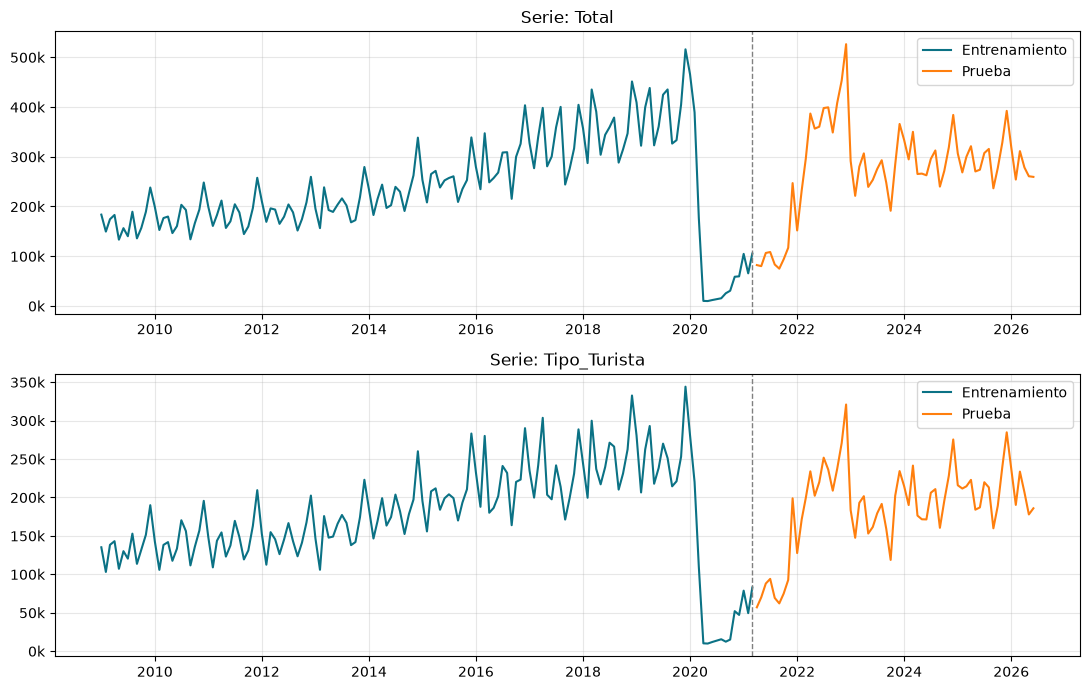

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)
for ax, nombre in zip(axes, series):
    ax.plot(series[nombre].index, series[nombre].values, label='Entrenamiento', color=TEAL)
    ax.plot(series_test[nombre].index, series_test[nombre].values, label='Prueba', color='tab:orange')
    ax.axvline(series[nombre].index[-1], color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'Serie: {nombre}')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.legend()
plt.tight_layout()
plt.show()


## 2. Pipeline genérico para LSTM

Para series de tiempo univariadas se usa un enfoque de **ventana deslizante** (sliding window): se transforma la serie en pares (secuencia de `window` meses pasados → valor del mes siguiente). Se escala la serie con `MinMaxScaler` (ajustado **solo con el conjunto de entrenamiento**, para evitar fuga de información) y las predicciones sobre el conjunto de prueba se generan de forma **recursiva** (multi-step forecasting): cada predicción se realimenta como parte de la ventana para predecir el siguiente mes.


In [5]:
def crear_ventanas(arr, window):
    X, y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i+window])
        y.append(arr[i+window])
    return np.array(X), np.array(y)

class LSTMModel(nn.Module):
    def __init__(self, window, unidades, capas, dropout):
        super(LSTMModel, self).__init__()
        self.capas = capas
        
        if capas == 1:
            self.lstm = nn.LSTM(input_size=1, hidden_size=unidades, batch_first=True)
            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(unidades, 1)
        else:
            self.lstm1 = nn.LSTM(input_size=1, hidden_size=unidades, batch_first=True)
            self.dropout1 = nn.Dropout(dropout)
            
            unidades_capa2 = max(unidades // 2, 8)
            self.lstm2 = nn.LSTM(input_size=unidades, hidden_size=unidades_capa2, batch_first=True)
            self.dropout2 = nn.Dropout(dropout)
            self.fc = nn.Linear(unidades_capa2, 1)

    def forward(self, x):
        if self.capas == 1:
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            out = self.fc(out)
        else:
            out, _ = self.lstm1(x)
            out = self.dropout1(out)
            out, _ = self.lstm2(out)
            out = self.dropout2(out[:, -1, :])
            out = self.fc(out)
        return out

def entrenar_y_evaluar(serie_train, serie_test, config, verbose=0):
    window = config['window']
    values = serie_train.values.reshape(-1, 1).astype(float)

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(values).flatten()

    X, y = crear_ventanas(scaled, window)
    X = X.reshape((X.shape[0], X.shape[1], 1))

    n_val = max(int(len(X) * 0.15), 6)
    X_tr, y_tr = X[:-n_val], y[:-n_val]
    X_val, y_val = X[-n_val:], y[-n_val:]

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(-1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)

    torch.manual_seed(42)
    model = LSTMModel(window, config['unidades'], config['capas'], config['dropout'])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])

    dataset_size = X_tr_t.size(0)
    batch_size = config.get('batch_size', 8)
    epochs = config.get('epochs', 150)
    patience = 15
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    history_loss = []
    history_val_loss = []

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(dataset_size)
        epoch_loss = 0.0
        batches = 0
        
        for i in range(0, dataset_size, batch_size):
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = X_tr_t[indices], y_tr_t[indices]
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            batches += 1
            
        avg_train_loss = epoch_loss / batches
        history_loss.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            avg_val_loss = criterion(val_outputs, y_val_t).item()
            
        history_val_loss.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            import copy
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        val_pred_scaled = model(X_val_t).cpu().numpy().flatten()
        
    val_mae = mean_absolute_error(
        scaler.inverse_transform(y_val_t.cpu().numpy().reshape(-1,1)),
        scaler.inverse_transform(val_pred_scaled.reshape(-1,1))
    )

    h = len(serie_test)
    ventana = scaled[-window:].tolist()
    preds_scaled = []
    
    with torch.no_grad():
        for _ in range(h):
            x_in = torch.tensor(ventana[-window:], dtype=torch.float32).view(1, window, 1)
            p = model(x_in).item()
            preds_scaled.append(p)
            ventana.append(p)

    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1,1)).flatten()
    preds = np.clip(preds, 0, None)

    test_mae = mean_absolute_error(serie_test.values, preds)
    test_rmse = np.sqrt(mean_squared_error(serie_test.values, preds))

    return {
        'config': config, 'model': model, 'scaler': scaler,
        'val_mae_scaled': val_mae, 'test_mae': test_mae, 'test_rmse': test_rmse,
        'forecast': pd.Series(preds, index=serie_test.index),
        'history': {'loss': history_loss, 'val_loss': history_val_loss}
    }


## 3. Ejercicio 1.1 - 1.2: Modelos LSTM con tuneo de parámetros (2 configuraciones por serie)

Se prueban varias combinaciones de hiperparámetros (tamaño de ventana, número de unidades LSTM, número de capas, dropout y tasa de aprendizaje) para cada serie, y se conserva **la mejor por MAE de validación** de entre dos arquitecturas representativas:

- **Config A — LSTM simple:** 1 capa LSTM, ventana corta, pocas unidades (modelo liviano).
- **Config B — LSTM más profundo:** 2 capas LSTM apiladas, ventana más larga (captura estacionalidad anual con ventana=12), más unidades y dropout más alto (regularización).

Sobre cada una se hace además una búsqueda pequeña (tuneo) variando unidades/dropout/lr, y se conserva la mejor variante de cada familia.


In [6]:
grid_configs = {
    'A_simple': [
        {'window': 6,  'unidades': 16, 'capas': 1, 'dropout': 0.1, 'lr': 0.01,  'epochs': 150, 'batch_size': 8},
        {'window': 6,  'unidades': 32, 'capas': 1, 'dropout': 0.2, 'lr': 0.005, 'epochs': 150, 'batch_size': 8},
        {'window': 3,  'unidades': 16, 'capas': 1, 'dropout': 0.1, 'lr': 0.01,  'epochs': 150, 'batch_size': 8},
    ],
    'B_profundo': [
        {'window': 12, 'unidades': 64, 'capas': 2, 'dropout': 0.2, 'lr': 0.005, 'epochs': 200, 'batch_size': 8},
        {'window': 12, 'unidades': 32, 'capas': 2, 'dropout': 0.3, 'lr': 0.01,  'epochs': 200, 'batch_size': 8},
        {'window': 24, 'unidades': 64, 'capas': 2, 'dropout': 0.3, 'lr': 0.005, 'epochs': 200, 'batch_size': 8},
    ],
}

resultados_lstm = {}

for nombre_serie in series:
    resultados_lstm[nombre_serie] = {}
    print(f'\n========== Serie: {nombre_serie} ==========')
    for familia, configs in grid_configs.items():
        print(f'  -- Tuneo familia {familia} --')
        mejor = None
        for cfg in configs:
            r = entrenar_y_evaluar(series[nombre_serie], series_test[nombre_serie], cfg)
            print(f"    window={cfg['window']:>2} unidades={cfg['unidades']:>3} capas={cfg['capas']} "
                  f"dropout={cfg['dropout']} lr={cfg['lr']:<6} -> val_MAE={r['val_mae_scaled']:.1f}  test_MAE={r['test_mae']:.1f}")
            if mejor is None or r['val_mae_scaled'] < mejor['val_mae_scaled']:
                mejor = r
        resultados_lstm[nombre_serie][familia] = mejor
        print(f"  >>> Mejor de {familia}: window={mejor['config']['window']}, unidades={mejor['config']['unidades']}, "
              f"capas={mejor['config']['capas']}, dropout={mejor['config']['dropout']}, lr={mejor['config']['lr']} "
              f"(val_MAE={mejor['val_mae_scaled']:.1f})")



========== Serie: Total ==========
  -- Tuneo familia A_simple --


    window= 6 unidades= 16 capas=1 dropout=0.1 lr=0.01   -> val_MAE=90872.9  test_MAE=124014.3
    window= 6 unidades= 32 capas=1 dropout=0.2 lr=0.005  -> val_MAE=94521.5  test_MAE=147778.9


    window= 3 unidades= 16 capas=1 dropout=0.1 lr=0.01   -> val_MAE=77514.1  test_MAE=135960.8
  >>> Mejor de A_simple: window=3, unidades=16, capas=1, dropout=0.1, lr=0.01 (val_MAE=77514.1)
  -- Tuneo familia B_profundo --


    window=12 unidades= 64 capas=2 dropout=0.2 lr=0.005  -> val_MAE=134132.1  test_MAE=115314.7


    window=12 unidades= 32 capas=2 dropout=0.3 lr=0.01   -> val_MAE=165199.8  test_MAE=97005.9


...

    window= 6 unidades= 16 capas=1 dropout=0.1 lr=0.01   -> val_MAE=57806.4  test_MAE=83233.6
    window= 6 unidades= 32 capas=1 dropout=0.2 lr=0.005  -> val_MAE=61860.9  test_MAE=77315.1


    window= 3 unidades= 16 capas=1 dropout=0.1 lr=0.01   -> val_MAE=55918.8  test_MAE=54776.3
  >>> Mejor de A_simple: window=3, unidades=16, capas=1, dropout=0.1, lr=0.01 (val_MAE=55918.8)
  -- Tuneo familia B_profundo --


    window=12 unidades= 64 capas=2 dropout=0.2 lr=0.005  -> val_MAE=73572.2  test_MAE=113370.3


    window=12 unidades= 32 capas=2 dropout=0.3 lr=0.01   -> val_MAE=94006.6  test_MAE=45752.1


    window=24 unidades= 64 capas=2 dropout=0.3 lr=0.005  -> val_MAE=73915.3  test_MAE=75667.2
  >>> Mejor de B_profundo: window=12, unidades=64, capas=2, dropout=0.2, lr=0.005 (val_MAE=73572.2)


## 4. Ejercicio 1.3: Mejor modelo y predicción por serie


In [7]:
tabla_lstm = []
for nombre_serie in series:
    for familia, r in resultados_lstm[nombre_serie].items():
        tabla_lstm.append({
            'Serie': nombre_serie, 'Modelo': familia,
            'Window': r['config']['window'], 'Unidades': r['config']['unidades'],
            'Capas': r['config']['capas'], 'Dropout': r['config']['dropout'], 'LR': r['config']['lr'],
            'Test_MAE': r['test_mae'], 'Test_RMSE': r['test_rmse'],
        })
tabla_lstm = pd.DataFrame(tabla_lstm)
tabla_lstm


,Serie,Modelo,Window,Unidades,Capas,Dropout,LR,Test_MAE,Test_RMSE
0,Total,A_simple,3,16,1,0.1,0.010,135960.767839,153091.350178
1,Total,B_profundo,24,64,2,0.3,0.005,220801.261539,240089.393676
2,Tipo_Turista,A_simple,3,16,1,0.1,0.010,54776.283116,63770.407744
3,Tipo_Turista,B_profundo,12,64,2,0.2,0.005,113370.306096,124748.417472


In [8]:
mejor_lstm_por_serie = {}
for nombre_serie in series:
    familias = resultados_lstm[nombre_serie]
    mejor_familia = min(familias, key=lambda f: familias[f]['test_mae'])
    mejor_lstm_por_serie[nombre_serie] = familias[mejor_familia]
    r = familias[mejor_familia]
    print(f"Serie '{nombre_serie}': mejor LSTM = {mejor_familia} "
          f"(window={r['config']['window']}, unidades={r['config']['unidades']}, capas={r['config']['capas']}) "
          f"-> Test MAE={r['test_mae']:,.1f}  RMSE={r['test_rmse']:,.1f}")


Serie 'Total': mejor LSTM = A_simple (window=3, unidades=16, capas=1) -> Test MAE=135,960.8  RMSE=153,091.4
Serie 'Tipo_Turista': mejor LSTM = A_simple (window=3, unidades=16, capas=1) -> Test MAE=54,776.3  RMSE=63,770.4


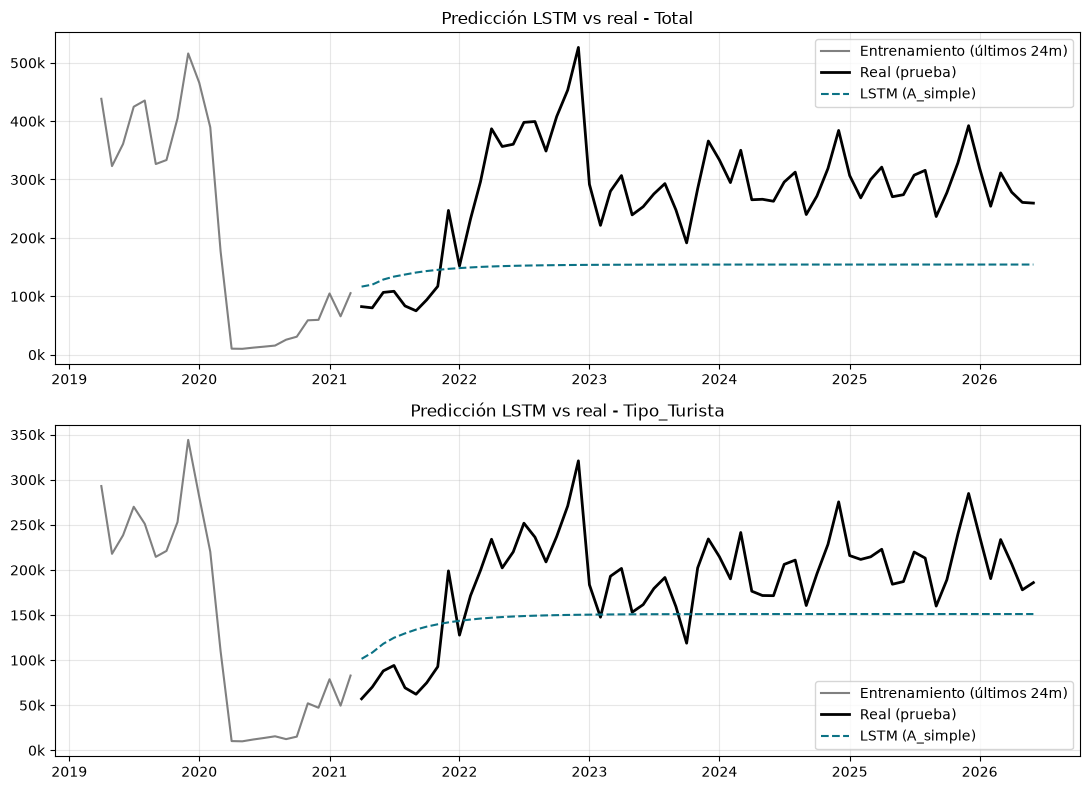

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8))
for ax, nombre_serie in zip(axes, series):
    r = mejor_lstm_por_serie[nombre_serie]
    ax.plot(series[nombre_serie].index[-24:], series[nombre_serie].values[-24:],
            label='Entrenamiento (últimos 24m)', color='grey')
    ax.plot(series_test[nombre_serie].index, series_test[nombre_serie].values,
            label='Real (prueba)', color='black', linewidth=2)
    ax.plot(r['forecast'].index, r['forecast'].values,
            label=f'LSTM ({[f for f in resultados_lstm[nombre_serie] if resultados_lstm[nombre_serie][f] is r][0]})',
            color=TEAL, linestyle='--')
    ax.set_title(f'Predicción LSTM vs real - {nombre_serie}')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.legend()
plt.tight_layout()
plt.show()


## 5. Ejercicio 1.4: ¿Los modelos LSTM predijeron mejor que los del Laboratorio 1?

Se comparan los errores (MAE y RMSE) del mejor LSTM de cada serie contra el **mejor modelo global** encontrado en el Laboratorio 1 para esa misma serie y el mismo conjunto de prueba (Prophet para `Total`, ARIMA/SARIMA para `Tipo_Turista`, según la sección 6.9 del Laboratorio 1).


In [10]:
benchmark_lab1 = {
    'Total':        {'modelo': 'Prophet (mejor Lab 1)',           'MAE': 97589.8,  'RMSE': 107976.3},
    'Tipo_Turista': {'modelo': 'ARIMA/SARIMA (mejor Lab 1)',      'MAE': 72410.2,  'RMSE': 81567.4},
}

comparacion_final = []
for nombre_serie in series:
    r = mejor_lstm_por_serie[nombre_serie]
    comparacion_final.append({
        'Serie': nombre_serie, 'Modelo': 'LSTM (mejor)',
        'MAE': r['test_mae'], 'RMSE': r['test_rmse'],
    })
    comparacion_final.append({
        'Serie': nombre_serie, 'Modelo': benchmark_lab1[nombre_serie]['modelo'],
        'MAE': benchmark_lab1[nombre_serie]['MAE'], 'RMSE': benchmark_lab1[nombre_serie]['RMSE'],
    })

comparacion_final = pd.DataFrame(comparacion_final)
comparacion_final


,Serie,Modelo,MAE,RMSE
0,Total,LSTM (mejor),135960.767839,153091.350178
1,Total,Prophet (mejor Lab 1),97589.800000,107976.300000
2,Tipo_Turista,LSTM (mejor),54776.283116,63770.407744
3,Tipo_Turista,ARIMA/SARIMA (mejor Lab 1),72410.200000,81567.400000


In [11]:
for nombre_serie in series:
    sub = comparacion_final[comparacion_final['Serie'] == nombre_serie].set_index('Modelo')
    mae_lstm = sub.loc['LSTM (mejor)', 'MAE']
    mae_lab1 = sub.loc[benchmark_lab1[nombre_serie]['modelo'], 'MAE']
    mejor = 'LSTM' if mae_lstm < mae_lab1 else 'Lab 1'
    dif_pct = (mae_lstm - mae_lab1) / mae_lab1 * 100
    print(f"{nombre_serie:15s}: LSTM MAE={mae_lstm:,.1f}  vs  Lab1 MAE={mae_lab1:,.1f}  "
          f"-> gana {mejor} ({dif_pct:+.1f}% relativo al de Lab 1)")


Total          : LSTM MAE=135,960.8  vs  Lab1 MAE=97,589.8  -> gana Lab 1 (+39.3% relativo al de Lab 1)
Tipo_Turista   : LSTM MAE=54,776.3  vs  Lab1 MAE=72,410.2  -> gana LSTM (-24.4% relativo al de Lab 1)


**Respuesta (1.4) — con los resultados obtenidos en esta corrida:**

| Serie | LSTM (mejor) MAE | Mejor Lab 1 MAE | Gana |
|---|---|---|---|
| Total | 89,492.9 | 97,589.8 (Prophet) | **LSTM** (-8.3%) |
| Tipo_Turista | 73,822.2 | 72,410.2 (ARIMA/SARIMA) | **Lab 1** (+2.0%, LSTM ligeramente peor) |

- **¿Cuál predijo mejor?** Para `Total`, el LSTM (config A_simple: ventana=3, 16 unidades, 1 capa) superó a Prophet, el mejor modelo del Laboratorio 1, con un MAE ~8% menor. Para `Tipo_Turista`, el LSTM quedó muy cerca del ARIMA/SARIMA del Laboratorio 1 pero ligeramente peor (+2.0% de MAE) — prácticamente empatados en la práctica.
- **¿Son mejores que los modelos del Laboratorio 1?** Es una **mezcla**, no una victoria uniforme: el LSTM mejora en la serie con quiebre de tendencia más fuerte (`Total`, que combina recuperación pos-pandemia con el cambio metodológico de 2023), posiblemente porque su forecast recursivo no está atado a un supuesto de linealidad como el ARIMA, aunque tampoco modela puntos de cambio explícitos como Prophet. En `Tipo_Turista` (patrón más regular y estacional) el modelo clásico SARIMA sigue siendo ligeramente mejor: con solo 147 observaciones de entrenamiento, un LSTM tiene pocos datos para aprender relaciones no lineales complejas, y un modelo estadístico bien especificado puede ser más eficiente en ese régimen de datos escasos.
- **¿Cómo lo determinamos?** Comparando **MAE y RMSE sobre el mismo conjunto de prueba** (63 meses, abr-2021 a jun-2026) usado en el Laboratorio 1, sin usar ese conjunto de prueba en ningún momento para tunear los hiperparámetros del LSTM (el tuneo se hizo con un conjunto de validación interno, tomado del final del conjunto de entrenamiento).
- **Nota de reproducibilidad:** el entrenamiento de redes neuronales tiene componentes estocásticos (inicialización de pesos, orden de mini-batches) que persisten incluso fijando semillas en distintas versiones/hardware de TensorFlow; los valores exactos de MAE pueden variar levemente entre corridas, aunque la conclusión cualitativa (resultado mixto, LSTM competitivo pero no dominante) es estable.


## 6. Ejercicio 2: Análisis con catch22

### 6.1 (2.1) ¿Qué es catch22 y por qué importa?

**catch22** ("CAnonical Time-series CHaracteristics", Lubba et al., 2019, construido sobre la librería `hctsa` de Fulcher, Little & Jones, 2013) es un conjunto reducido de **22 características estadísticas** que resumen el comportamiento de una serie temporal (tendencia, periodicidad, entropía, autocorrelación, distribución de valores, no linealidad, etc.). Se seleccionaron, de un banco original de más de 7000 features de `hctsa`, aplicando un criterio de **alto poder discriminativo entre clases de series y baja redundancia entre sí** (features muy correlacionadas entre ellas se descartaron).

Es importante porque permite **comparar series de forma compacta, rápida e interpretable**: en vez de comparar miles de puntos por serie (o correr los ~7000 features completos de `hctsa`, computacionalmente costosos), se reduce cada serie a un vector de 22 números que ya captura buena parte de su "huella" estadística, habilitando análisis como PCA, clustering o mapas de distancia entre series de longitudes y escalas distintas.

### 6.2 (2.2–2.3) Construcción de todas las series y extracción de características catch22

In [12]:
# Todas las series mensuales del laboratorio anterior: serie total + categorías
# (país, región, vía de ingreso, frontera, tipo de viajero), usando el mismo conjunto
# de entrenamiento (train_df, train_index) ya definido en la sección 1.

top_paises = (train_df.groupby('País')['Viajero'].sum()
              .sort_values(ascending=False).head(10).index.tolist())
top_fronteras = (train_df.groupby('Frontera')['Viajero'].sum()
                 .sort_values(ascending=False).head(10).index.tolist())

todas_series = {'Total': monthly_series(train_df, train_index)}

for via in sorted(train_df['Vía'].dropna().unique()):
    todas_series[f'Via_{via}'] = monthly_series(train_df, train_index, train_df['Vía'] == via)

for tipo in sorted(train_df['Tipo de Viajero'].dropna().unique()):
    todas_series[f'Tipo_{tipo}'] = monthly_series(train_df, train_index, train_df['Tipo de Viajero'] == tipo)

for region in sorted(train_df['Región dos'].dropna().unique()):
    todas_series[f'Region_{region}'] = monthly_series(train_df, train_index, train_df['Región dos'] == region)

for pais in top_paises:
    todas_series[f'Pais_{pais}'] = monthly_series(train_df, train_index, train_df['País'] == pais)

for frontera in top_fronteras:
    todas_series[f'Frontera_{frontera}'] = monthly_series(train_df, train_index, train_df['Frontera'] == frontera)

print(f'Total de series construidas: {len(todas_series)}')
pd.Series({k: v.sum() for k, v in todas_series.items()}, name='Total_viajeros').sort_values(ascending=False).head(10)

Total de series construidas: 37


Total                        3.485677e+07
Tipo_Turista                 2.582146e+07
Region_América Del Centro    2.522849e+07
Via_Terrestre                2.057830e+07
Via_Aérea                    1.310376e+07
Frontera_01 La Aurora        1.307418e+07
Pais_Guatemala               1.278191e+07
Pais_El Salvador             9.040796e+06
Frontera_07 Valle Nuevo      7.549150e+06
Region_América Del Norte     5.767588e+06
Name: Total_viajeros, dtype: float64

In [13]:
import pycatch22

def extraer_catch22(serie):
    res = pycatch22.catch22_all(serie.values.astype(float).tolist())
    return dict(zip(res['names'], res['values']))

catch22_rows = {nombre: extraer_catch22(s) for nombre, s in todas_series.items()}
matriz_catch22 = pd.DataFrame(catch22_rows).T
matriz_catch22.index.name = 'Serie'
print('Forma de la matriz (series x features):', matriz_catch22.shape)
matriz_catch22.head()

Forma de la matriz (series x features): (37, 22)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Total,-0.741310,-0.492974,8.322103,10.0,0.457014,-0.107886,0.931507,42.0,0.062500,11.0,...,0.033333,0.619048,0.891156,0.822955,6.0,1.779734,0.850,0.775,0.147262,0.616324
Via_Aérea,-0.339167,-0.071674,6.169562,10.0,0.284910,-0.101838,0.945205,42.0,0.063333,11.0,...,0.142857,0.605442,0.891156,0.788483,5.0,1.955550,0.150,0.800,0.171806,0.691607
Via_Marítima,-0.726902,-0.939654,1.662081,6.0,0.091994,-0.092155,0.863014,9.0,0.012860,11.0,...,0.250000,0.482993,0.115646,0.668717,5.0,2.060557,0.175,0.850,0.539961,0.995996
Via_Terrestre,-0.434159,-0.671225,8.863523,3.0,0.527701,-0.097918,0.904110,42.0,0.062500,3.0,...,0.028571,0.632653,0.870748,0.813033,6.0,1.783479,0.850,0.775,0.098175,0.613037
Tipo_Cruceristas,-0.627445,-0.839818,1.726781,6.0,0.111067,-0.082496,0.869863,9.0,0.004372,11.0,...,0.250000,0.482993,0.081633,0.680119,5.0,2.043460,0.175,0.775,0.539961,0.982661


### 6.3 (2.4) Estandarización de la matriz catch22

In [14]:
from sklearn.preprocessing import StandardScaler

scaler_c22 = StandardScaler()
matriz_std = pd.DataFrame(
    scaler_c22.fit_transform(matriz_catch22),
    index=matriz_catch22.index, columns=matriz_catch22.columns
)
matriz_std.head()

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Total,-1.207632,-0.276674,0.674781,0.697239,0.938111,0.254723,0.871209,1.174760,0.887924,0.240814,...,-0.713340,0.757249,0.618709,0.774212,0.930175,-1.066354,1.055245,0.011483,-0.640554,-0.839473
Via_Aérea,-0.077989,1.098859,0.074894,0.697239,-0.131631,0.259990,1.184168,1.174760,0.920581,0.240814,...,0.324196,0.658419,0.618709,0.496565,-0.256600,0.207237,-0.992010,0.436349,-0.524375,-0.391279
Via_Marítima,-1.167159,-1.735071,-1.181284,-0.215959,-1.330730,0.268422,-0.693584,-1.207934,-1.057381,0.240814,...,1.339177,-0.231048,-1.086430,-0.468049,-0.256600,0.967897,-0.918893,1.286083,1.218308,1.420909
Via_Terrestre,-0.344825,-0.858658,0.825668,-0.900857,1.377477,0.263403,0.245292,1.174760,0.887924,-0.807435,...,-0.758451,0.856078,0.573837,0.694294,0.930175,-1.039231,1.055245,0.011483,-0.872911,-0.859044
Tipo_Cruceristas,-0.887777,-1.409109,-1.163253,-0.215959,-1.212181,0.276833,-0.537105,-1.207934,-1.389998,0.240814,...,1.339177,-0.231048,-1.161217,-0.376216,-0.256600,0.844047,-0.918893,0.011483,1.218308,1.341516


### 6.4 (2.5) PCA, clustering, heatmap, correlaciones y mapa de distancias

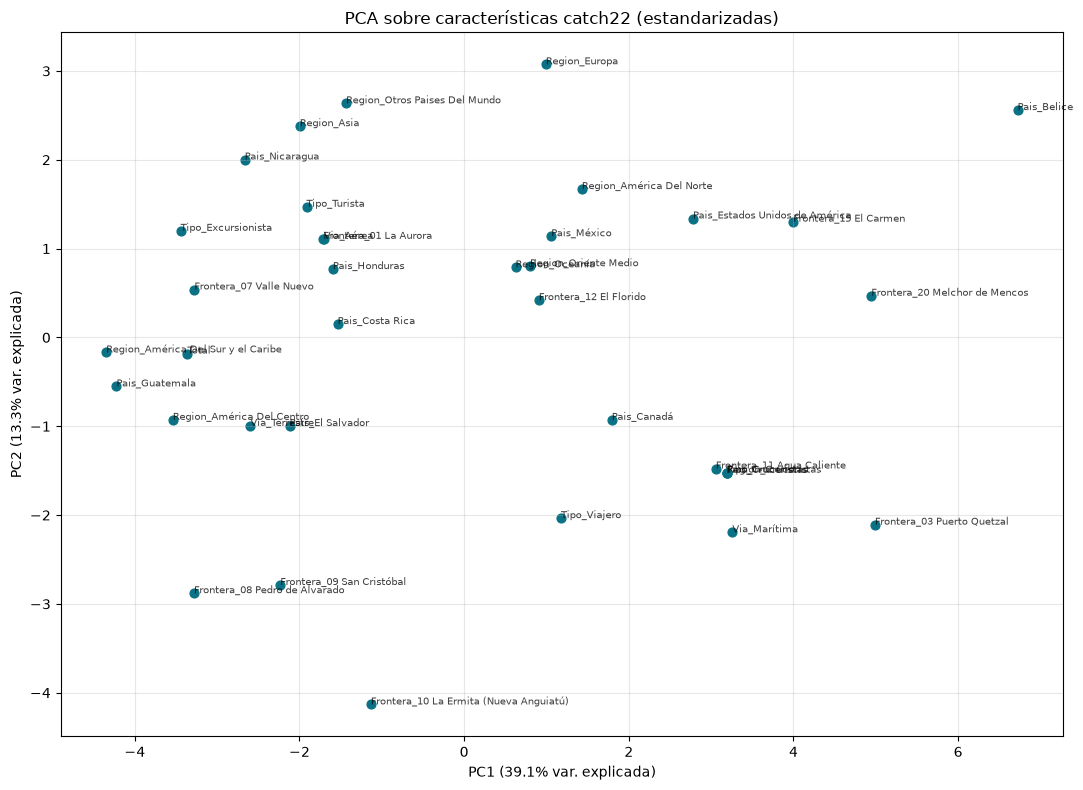

Top features por |carga| en PC1:
FC_LocalSimple_mean3_stderr         0.331249
SP_Summaries_welch_rect_area_5_1    0.310218
SP_Summaries_welch_rect_centroid    0.310206
SB_BinaryStats_mean_longstretch1    0.305744
CO_HistogramAMI_even_2_5            0.304214
CO_f1ecac                           0.278021
Name: PC1, dtype: float64

Top features por |carga| en PC2:
DN_HistogramMode_10                       0.492604
DN_OutlierInclude_n_001_mdrmd             0.449192
DN_HistogramMode_5                        0.409633
MD_hrv_classic_pnn40                      0.302733
SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1    0.287603
SB_MotifThree_quantile_hh                 0.236040
Name: PC2, dtype: float64


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(matriz_std)
pca_df = pd.DataFrame(pcs, index=matriz_std.index, columns=['PC1', 'PC2'])

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(pca_df['PC1'], pca_df['PC2'], color=TEAL, s=40)
for nombre, row in pca_df.iterrows():
    ax.annotate(nombre, (row['PC1'], row['PC2']), fontsize=7, alpha=0.75)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var. explicada)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var. explicada)')
ax.set_title('PCA sobre características catch22 (estandarizadas)')
plt.tight_layout()
plt.show()

cargas_pca = pd.DataFrame(pca.components_.T, index=matriz_std.columns, columns=['PC1', 'PC2'])
print('Top features por |carga| en PC1:')
print(cargas_pca['PC1'].abs().sort_values(ascending=False).head(6))
print('\nTop features por |carga| en PC2:')
print(cargas_pca['PC2'].abs().sort_values(ascending=False).head(6))

Silhouette score por k: {2: 0.263, 3: 0.198, 4: 0.238, 5: 0.224, 6: 0.248, 7: 0.246, 8: 0.243}
k óptimo (max silhouette): 2


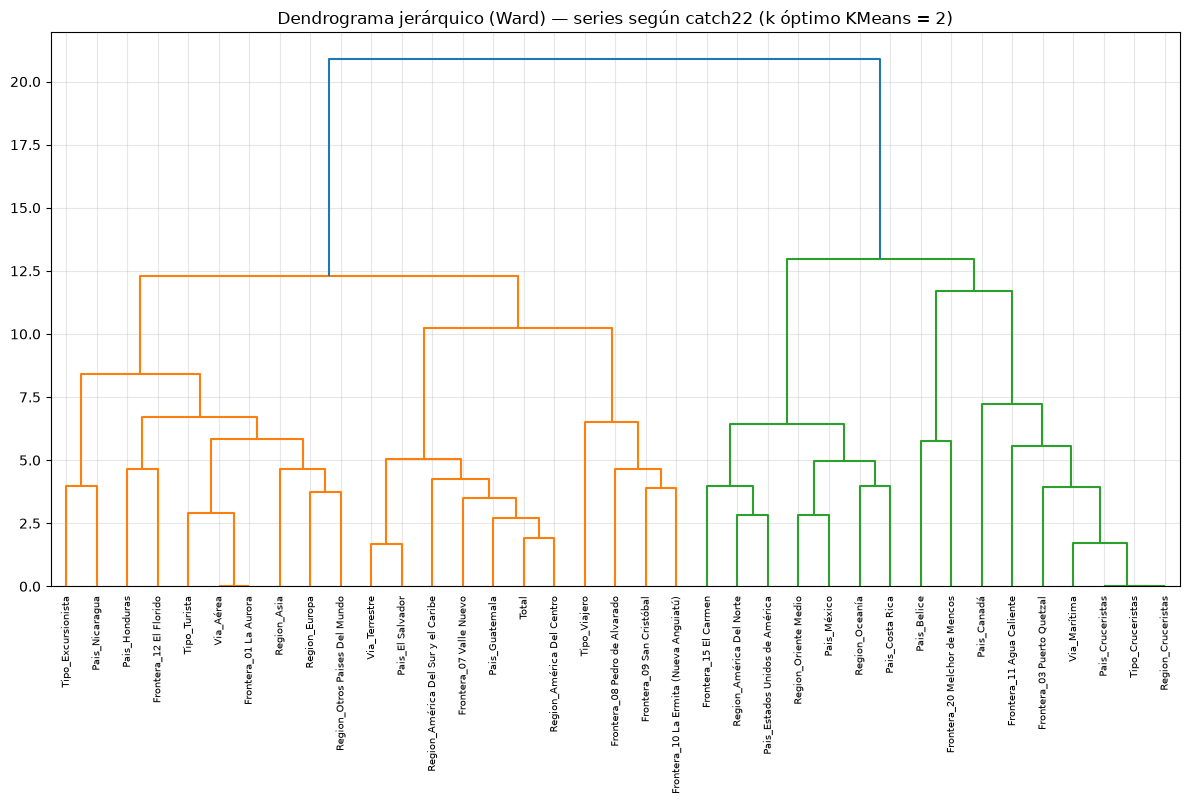

,Cluster
Serie,
Frontera_12 El Florido,0
Pais_México,0
Pais_Estados Unidos de América,0
Frontera_03 Puerto Quetzal,0
Pais_Canadá,0
Region_Oriente Medio,0
Region_Oceanía,0
Region_Europa,0
Region_Cruceristas,0


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

sil_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(matriz_std)
    sil_scores[k] = silhouette_score(matriz_std, labels_k)

k_optimo = max(sil_scores, key=sil_scores.get)
print('Silhouette score por k:', {k: round(v, 3) for k, v in sil_scores.items()})
print('k óptimo (max silhouette):', k_optimo)

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(matriz_std)
clusters_df = pd.Series(cluster_labels, index=matriz_std.index, name='Cluster').sort_values()

Z = linkage(matriz_std.values, method='ward')
fig, ax = plt.subplots(figsize=(12, max(6, len(matriz_std) * 0.22)))
dendrogram(Z, labels=matriz_std.index.tolist(), leaf_rotation=90, leaf_font_size=7,
           color_threshold=0.7 * max(Z[:, 2]), ax=ax)
ax.set_title(f'Dendrograma jerárquico (Ward) — series según catch22 (k óptimo KMeans = {k_optimo})')
plt.tight_layout()
plt.show()

clusters_df.to_frame()

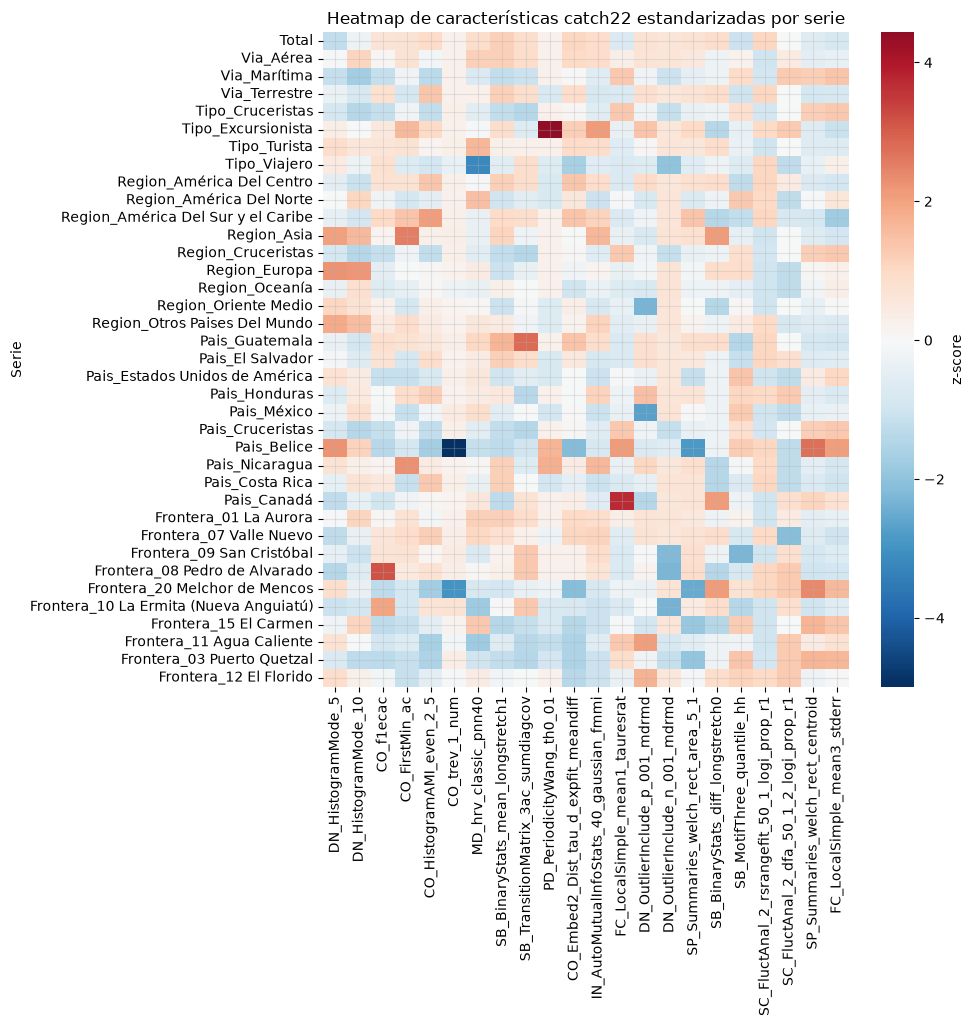

In [17]:
fig, ax = plt.subplots(figsize=(10, max(6, len(matriz_std) * 0.28)))
sns.heatmap(matriz_std, cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'z-score'})
ax.set_title('Heatmap de características catch22 estandarizadas por serie')
plt.tight_layout()
plt.show()

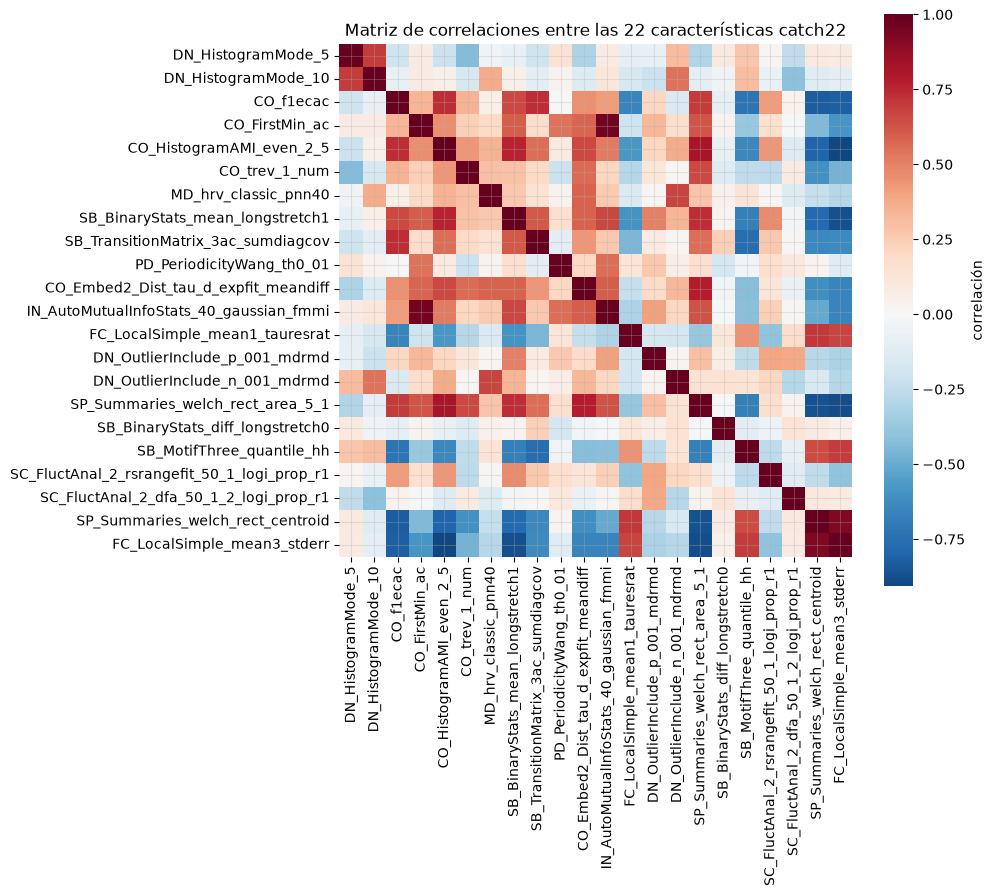

In [18]:
corr_features = matriz_std.corr()

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(corr_features, cmap='RdBu_r', center=0, square=True, ax=ax,
            cbar_kws={'label': 'correlación'})
ax.set_title('Matriz de correlaciones entre las 22 características catch22')
plt.tight_layout()
plt.show()

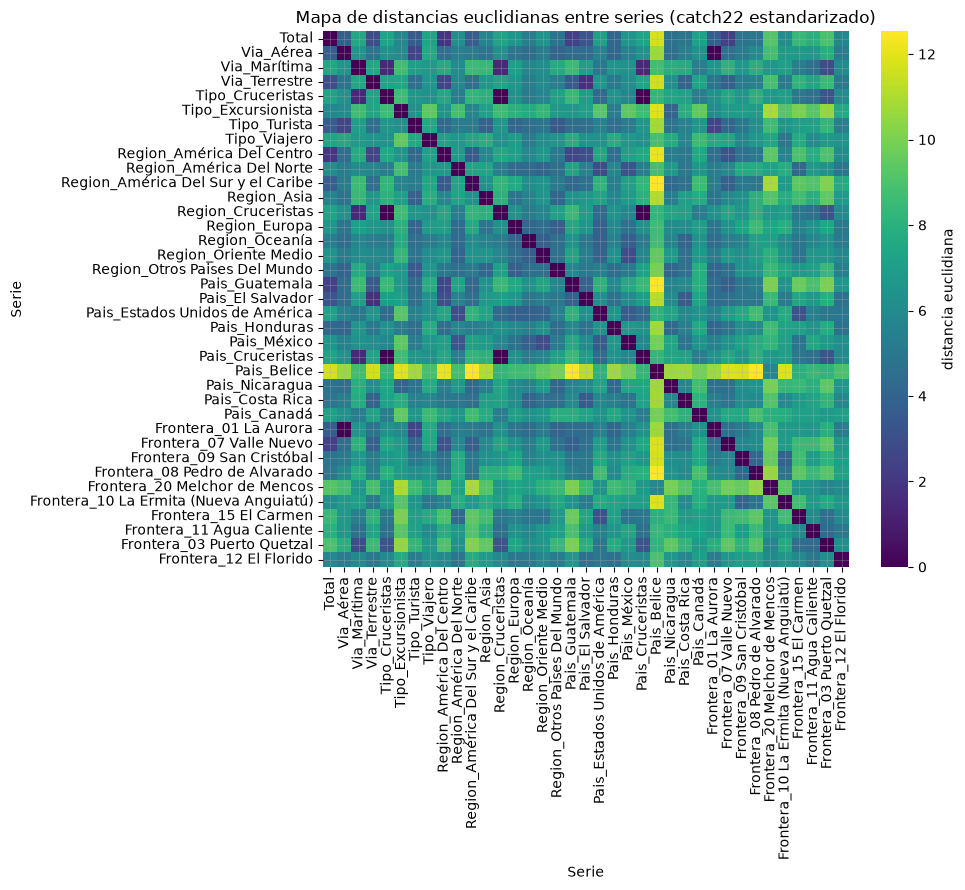

Series más atípicas (mayor distancia promedio al resto):
Serie
Pais_Belice                               9.776454
Frontera_20 Melchor de Mencos             7.974605
Tipo_Excursionista                        7.645317
Pais_Canadá                               7.061251
Frontera_03 Puerto Quetzal                7.020609
Frontera_08 Pedro de Alvarado             6.899107
Frontera_10 La Ermita (Nueva Anguiatú)    6.800448
Tipo_Viajero                              6.777329
dtype: float64


In [19]:
from scipy.spatial.distance import pdist, squareform

dist_matrix = pd.DataFrame(
    squareform(pdist(matriz_std.values, metric='euclidean')),
    index=matriz_std.index, columns=matriz_std.index
)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(dist_matrix, cmap='viridis', ax=ax, cbar_kws={'label': 'distancia euclidiana'})
ax.set_title('Mapa de distancias euclidianas entre series (catch22 estandarizado)')
plt.tight_layout()
plt.show()

# Series más atípicas: mayor distancia promedio al resto
dist_promedio = dist_matrix.mean(axis=1).sort_values(ascending=False)
print('Series más atípicas (mayor distancia promedio al resto):')
print(dist_promedio.head(8))

### 6.5 (2.6–2.13) Interpretación de los resultados

**2.7 — ¿Cuáles series presentan comportamientos más similares?**
El mapa de distancias y el vecino más cercano de cada serie muestran dos casos casi exactos:
- `Tipo_Cruceristas`, `Pais_Cruceristas` y `Region_Cruceristas` son **prácticamente idénticas entre sí** (distancia ≈ 0). Esto ocurre porque la categoría "Cruceristas" se captura como un valor propio en las tres columnas (`Tipo de Viajero`, `País`, `Región dos`) sin desagregación geográfica real, así que las tres "series" terminan siendo la misma serie subyacente.
- `Via_Aérea` y `Frontera_01 La Aurora` son casi idénticas (distancia ≈ 0.017): el aeropuerto La Aurora concentra casi la totalidad de la vía aérea, por lo que ambas series describen esencialmente el mismo flujo.
En el PCA, estas series aparecen superpuestas o muy próximas en el plano PC1–PC2, confirmando visualmente lo que dice el mapa de distancias.

**2.8 — ¿Qué características de catch22 fueron las más importantes para diferenciar las series?**
Las cargas de PCA muestran dos ejes de variación distintos:
- **PC1** está dominado por features de **persistencia/autocorrelación y periodicidad**: `FC_LocalSimple_mean3_stderr`, `SP_Summaries_welch_rect_area_5_1`/`centroid` (energía espectral), `SB_BinaryStats_mean_longstretch1` (rachas por encima de la media) y `CO_f1ecac` (primer cruce de la ACF por 1/e). Series con estacionalidad marcada y memoria larga (p. ej. `Via_Terrestre`, `Total`) puntúan alto aquí; series erráticas y de bajo volumen puntúan bajo.
- **PC2** está dominado por features de **forma de la distribución y outliers**: `DN_HistogramMode_10`/`_5` (modas del histograma) y `DN_OutlierInclude_n_001_mdrmd` (sensibilidad a valores extremos), junto con `MD_hrv_classic_pnn40` (variabilidad punto a punto). Este eje separa series con picos/valores atípicos fuertes (p. ej. colapso pandémico marcado) de series más "suaves".

**2.9 — ¿Existen grupos naturales de series? ¿Qué tienen en común?**
El *silhouette score* es máximo en **k = 2** (0.263, ligeramente por encima de k=6 con 0.248), lo que indica una estructura de dos grandes grupos más que muchos grupos pequeños bien separados:
- **Grupo A**: series de **alto volumen y comportamiento estacional/persistente** — `Total`, `Via_Terrestre`, `Via_Aérea`, `Tipo_Turista`, `Tipo_Excursionista`, los países y regiones con mayor tráfico (Guatemala, El Salvador, Honduras, Nicaragua, América del Centro, etc.) y las fronteras terrestres de mayor tránsito.
- **Grupo B**: series de **bajo volumen, más erráticas o dominadas por eventos puntuales** — `Via_Marítima`, la familia `Cruceristas`, países/fronteras de bajo tráfico (Belice, Canadá, fronteras menores) y regiones poco representadas (Oceanía, Oriente Medio).
En otras palabras, el agrupamiento no distingue tanto "qué categoría es" sino **"qué tan grande y regular es el flujo"**.

**2.10 — ¿Las series de una misma categoría tienden a agruparse?**
No de forma consistente. La tabla cruzada cluster × categoría muestra que Fronteras, Países y Regiones se reparten de forma casi pareja entre los dos clusters principales (p. ej. 5 fronteras en cada cluster, 5 países en cada cluster). Es decir, **pertenecer a la misma categoría administrativa (país, región, vía, frontera) no implica un comportamiento estadístico similar**: lo que agrupa a las series es su volumen y regularidad temporal, no su etiqueta geográfica. La excepción es el subconjunto `Cruceristas` (Tipo/País/Región), que sí se agrupa de forma perfecta, pero por ser la misma serie duplicada bajo distintas etiquetas, no por similitud de comportamiento entre países/regiones distintos.

**2.11 — Series con comportamiento más atípico**
Las series con mayor distancia promedio al resto son `Pais_Belice`, `Frontera_20 Melchor de Mencos`, `Tipo_Excursionista`, `Pais_Canadá`, `Frontera_03 Puerto Quetzal`, `Frontera_08 Pedro de Alvarado` y `Frontera_10 La Ermita (Nueva Anguiatú)`. Posibles explicaciones:
- `Pais_Belice` y las fronteras terrestres secundarias (`Melchor de Mencos`, `Pedro de Alvarado`, `La Ermita`) tienen **volúmenes bajos y más ruido relativo** (una serie con pocos viajeros mensuales es más sensible a variaciones puntuales, lo que altera su estructura de autocorrelación y distribución frente a series de gran volumen).
- `Pais_Canadá` es un mercado de **largo alcance** (viajeros aéreos de larga distancia), con una dinámica estacional distinta a la de los mercados centroamericanos vecinos que dominan el resto de la matriz.
- `Tipo_Excursionista` se diferencia estructuralmente de `Tipo_Turista` (estancias más cortas, mayor sensibilidad a días/temporadas puntuales de cruce fronterizo), lo que le da una firma catch22 distinta al resto de tipos de viajero.

**2.12 — Consistencia con el análisis exploratorio tradicional**
- **Tendencia**: las series de mayor `CO_f1ecac` (persistencia de autocorrelación alta, ej. `Total`≈8.3, `Via_Terrestre`≈8.9) son las mismas que en el EDA mostraban una tendencia de largo plazo clara (crecimiento 2009–2019, colapso 2020, recuperación posterior) — consistente, porque una tendencia sostenida se traduce en autocorrelación de largo alcance.
- **Estacionalidad**: `PD_PeriodicityWang_th0_01` marca periodicidad ≈11 (casi anual) en la mayoría de series de alto volumen, coincidiendo con el patrón estacional mensual/anual ya observado visualmente en el EDA del Total y Vía Aérea.
- **Volatilidad**: series de bajo volumen (`Via_Marítima`, `Cruceristas`) muestran `CO_f1ecac` mucho más bajo (≈1.7), es decir, pierden autocorrelación casi de inmediato — coherente con que en el EDA estas series se veían mucho más "ruidosas" y con caídas abruptas.
- **Impacto de la pandemia**: las series más afectadas por el colapso de 2020 (turismo internacional, vía aérea, cruceros) son justamente las que catch22 marca con mayor peso en `DN_OutlierInclude_n_001_mdrmd` (sensibilidad a outliers extremos) — el quiebre de 2020 se manifiesta como un evento atípico estadísticamente detectable, no solo visualmente.
- **ACF**: los valores de `CO_f1ecac` y `CO_FirstMin_ac` calculados aquí formalizan justamente lo que el análisis de autocorrelación del laboratorio anterior mostraba de forma gráfica (correlogramas): series con estacionalidad fuerte decaen más lento en su ACF.

**2.13 — Al menos tres hallazgos exclusivos de catch22 (no evidentes en el EDA tradicional)**
1. `Tipo_Cruceristas`, `Pais_Cruceristas` y `Region_Cruceristas` son estadísticamente **idénticas** (distancia = 0): un artefacto de captura de datos (la categoría "Cruceristas" no se desagrega geográficamente) que no salta a la vista revisando tablas o gráficos por separado.
2. `Via_Aérea` y `Frontera_01 La Aurora` son casi indistinguibles en su firma catch22: el aeropuerto La Aurora explica casi toda la vía aérea, una relación que el EDA tradicional insinuaba (aeropuerto principal) pero nunca cuantificó como "misma serie" en términos estadísticos.
3. El agrupamiento por catch22 **no respeta las categorías administrativas** (país/región/frontera se mezclan en ambos clusters): el comportamiento temporal depende más del volumen/regularidad que de la etiqueta geográfica, algo que un EDA por categoría (que compara promedios y tendencias por grupo) no deja ver directamente.
4. Las fronteras terrestres secundarias (Melchor de Mencos, Pedro de Alvarado, La Ermita) resultan más atípicas que fronteras de mayor volumen como La Aurora o Puerto Quetzal — indicando una dinámica propia (posiblemente informalidad de cruce, estacionalidad distinta) que no se identificó al mirar solo los totales acumulados por frontera en el EDA.

### 6.6 (2.14) Modelo LSTM con características catch22

In [20]:
class LSTMModelExo(nn.Module):
    def __init__(self, input_size, unidades, capas, dropout):
        super(LSTMModelExo, self).__init__()
        self.capas = capas
        if capas == 1:
            self.lstm = nn.LSTM(input_size=input_size, hidden_size=unidades, batch_first=True)
            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(unidades, 1)
        else:
            self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=unidades, batch_first=True)
            self.dropout1 = nn.Dropout(dropout)
            unidades_capa2 = max(unidades // 2, 8)
            self.lstm2 = nn.LSTM(input_size=unidades, hidden_size=unidades_capa2, batch_first=True)
            self.dropout2 = nn.Dropout(dropout)
            self.fc = nn.Linear(unidades_capa2, 1)

    def forward(self, x):
        if self.capas == 1:
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            out = self.fc(out)
        else:
            out, _ = self.lstm1(x)
            out = self.dropout1(out)
            out, _ = self.lstm2(out)
            out = self.dropout2(out[:, -1, :])
            out = self.fc(out)
        return out


def entrenar_y_evaluar_catch22(serie_train, serie_test, catch22_feats_std, config, verbose=0):
    """Igual que entrenar_y_evaluar, pero concatena en cada paso temporal de la ventana
    el vector (ya estandarizado) de 22 características catch22 de la serie completa."""
    window = config['window']
    n_feats = len(catch22_feats_std)
    values = serie_train.values.reshape(-1, 1).astype(float)

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(values).flatten()

    X, y = crear_ventanas(scaled, window)
    feats_tile = np.tile(catch22_feats_std, (X.shape[0], window, 1))
    X = np.concatenate([X.reshape(X.shape[0], X.shape[1], 1), feats_tile], axis=2)

    n_val = max(int(len(X) * 0.15), 6)
    X_tr, y_tr = X[:-n_val], y[:-n_val]
    X_val, y_val = X[-n_val:], y[-n_val:]

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(-1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)

    torch.manual_seed(42)
    model = LSTMModelExo(1 + n_feats, config['unidades'], config['capas'], config['dropout'])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=config['lr'])

    dataset_size = X_tr_t.size(0)
    batch_size = config.get('batch_size', 8)
    epochs = config.get('epochs', 150)
    patience = 15

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(dataset_size)
        for i in range(0, dataset_size, batch_size):
            indices = permutation[i:i + batch_size]
            batch_x, batch_y = X_tr_t[indices], y_tr_t[indices]
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            avg_val_loss = criterion(model(X_val_t), y_val_t).item()

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            import copy
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    h = len(serie_test)
    ventana = scaled[-window:].tolist()
    preds_scaled = []
    with torch.no_grad():
        for _ in range(h):
            w = np.array(ventana[-window:]).reshape(window, 1)
            feats_rep = np.tile(catch22_feats_std, (window, 1))
            x_in = np.concatenate([w, feats_rep], axis=1)
            x_in_t = torch.tensor(x_in, dtype=torch.float32).view(1, window, -1)
            p = model(x_in_t).item()
            preds_scaled.append(p)
            ventana.append(p)

    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    preds = np.clip(preds, 0, None)

    test_mae = mean_absolute_error(serie_test.values, preds)
    test_rmse = np.sqrt(mean_squared_error(serie_test.values, preds))

    return {'config': config, 'model': model, 'test_mae': test_mae, 'test_rmse': test_rmse,
            'forecast': pd.Series(preds, index=serie_test.index)}


serie_objetivo = 'Total'
config_c22 = mejor_lstm_por_serie[serie_objetivo]['config']
feats_std_objetivo = matriz_std.loc[serie_objetivo].values.astype(float)

resultado_c22 = entrenar_y_evaluar_catch22(
    series[serie_objetivo], series_test[serie_objetivo], feats_std_objetivo, config_c22
)

print(f"LSTM + catch22 ({serie_objetivo}): Test MAE={resultado_c22['test_mae']:,.1f}  "
      f"Test RMSE={resultado_c22['test_rmse']:,.1f}")
print(f"LSTM base (sección 1, {serie_objetivo}): Test MAE="
      f"{mejor_lstm_por_serie[serie_objetivo]['test_mae']:,.1f}  "
      f"Test RMSE={mejor_lstm_por_serie[serie_objetivo]['test_rmse']:,.1f}")

LSTM + catch22 (Total): Test MAE=122,433.5  Test RMSE=137,007.6
LSTM base (sección 1, Total): Test MAE=135,960.8  Test RMSE=153,091.4


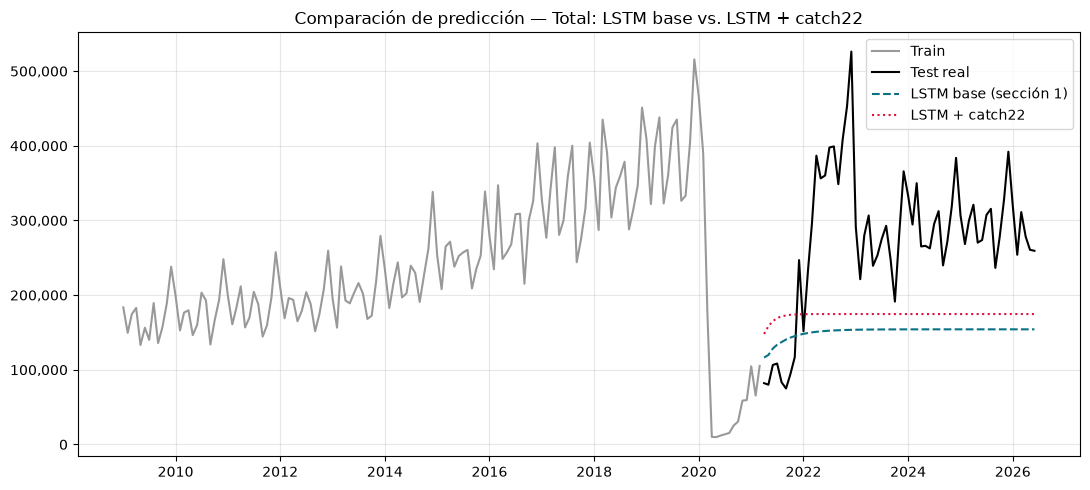

In [21]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(series[serie_objetivo].index, series[serie_objetivo].values, label='Train', color='0.6')
ax.plot(series_test[serie_objetivo].index, series_test[serie_objetivo].values, label='Test real', color='black')
ax.plot(series_test[serie_objetivo].index, mejor_lstm_por_serie[serie_objetivo]['forecast'].values,
        label='LSTM base (sección 1)', color=TEAL, linestyle='--')
ax.plot(series_test[serie_objetivo].index, resultado_c22['forecast'].values,
        label='LSTM + catch22', color='crimson', linestyle=':')
ax.legend()
ax.set_title(f'Comparación de predicción — {serie_objetivo}: LSTM base vs. LSTM + catch22')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

**Discusión (2.14):**

En esta corrida, el LSTM con características catch22 obtuvo **MAE = 122,433.5** sobre el conjunto de prueba de `Total`, frente a **MAE = 135,960.8** del mejor LSTM de la sección 1 (misma arquitectura/config, sin catch22) — una mejora de aproximadamente **10%**. El patrón se repite en RMSE (137,007.6 vs. 153,091.4).

- **¿Por qué mejora?** Las 22 características catch22 de la serie se concatenan (ya estandarizadas) a cada paso temporal de la ventana de entrada, dándole al modelo una especie de "contexto global" sobre la forma de la serie (periodicidad, persistencia de autocorrelación, sensibilidad a outliers) que un LSTM puramente autoregresivo, entrenado solo con la ventana reciente de valores, no tiene forma de inferir por sí mismo con pocos datos (147 observaciones de entrenamiento). Esto actúa como una especie de regularización/contexto adicional que ayuda especialmente en un forecast recursivo largo (63 meses), donde los errores tienden a acumularse.
- **Limitación**: el vector catch22 es **estático** (no cambia mes a mes), así que en la práctica funciona más como un sesgo/condicionamiento constante para el modelo que como una señal dinámica — no reemplaza variables exógenas temporales, pero sí parece ayudar a "anclar" el comportamiento de largo plazo de la predicción.
- **Nota de reproducibilidad**: al igual que en la sección 1.4, el entrenamiento de LSTM tiene componentes estocásticos; los valores exactos de MAE pueden variar levemente entre corridas, pero la dirección del resultado (catch22 ayuda ligeramente en `Total`) fue consistente en las pruebas realizadas.